# Part 1: Dataset Collection, Data Quality Audit & Exploratory Data Analysis (EDA)

1. Automated loading of StatsBomb 360 open datasets for **FIFA World Cup 2022**, **UEFA Euro 2020**, and **UEFA Euro 2024 (held-out test set)**.
2. Positional snapshot parsing and 360 geometric feature extraction (opponent proximity, defensive pressure rings, goal cone congestion, forward passing lanes).
3. Data quality checks: missingness, duplication, pitch bounds, and outlier diagnostics.
4. Comprehensive Exploratory Data Analysis (descriptive statistics, categorical breakdowns, spatial density heatmaps, possession chains).
5. Feature correlation analysis and feature selection recommendations for future VAEP prediction.
6. Generation and saving of all 6 publication-ready figures.


In [1]:
import os
import sys
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

# Set professional aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Competitions & Match Metadata

In [2]:
matches_wc = sb.matches(competition_id=43, season_id=106)
matches_euro = sb.matches(competition_id=55, season_id=43)
matches_euro24 = sb.matches(competition_id=55, season_id=282)

matches_wc['tournament'] = 'World Cup 2022'
matches_euro['tournament'] = 'Euro 2020'
matches_euro24['tournament'] = 'Euro 2024 (Held-out Test)'

all_matches = pd.concat([matches_wc, matches_euro, matches_euro24], ignore_index=True)
print(f"Total Matches Loaded Across 3 Tournaments: {len(all_matches)}")
print(f"- World Cup 2022: {len(matches_wc)} matches")
print(f"- Euro 2020: {len(matches_euro)} matches")
print(f"- Euro 2024 (Held-out): {len(matches_euro24)} matches")


Total Matches Loaded Across 3 Tournaments: 166
- World Cup 2022: 64 matches
- Euro 2020: 51 matches
- Euro 2024 (Held-out): 51 matches


## 2. Load Processed Events with 360 Snapshots & Data Quality Summary

In [3]:
df_events = pd.read_csv('data/sample_processed_events_with_360.csv')
print(f"Total events analyzed: {len(df_events):,}")
print(f"Events with 360 freeze frames: {df_events['has_360'].sum():,} ({df_events['has_360'].mean()*100:.2f}%)")
df_events.head(3)


Total events analyzed: 62,194
Events with 360 freeze frames: 53,207 (85.55%)


,event_id,match_id,tournament,period,minute,second,timestamp,type,sub_type,possession,...,has_360,teammates_visible,opponents_visible,total_visible,closest_opp_dist,closest_teammate_dist,opponents_within_3m,opponents_within_5m,defenders_in_goal_cone,forward_passing_options
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,3869685,World Cup 2022,1,0,0,00:00:00.000,Starting XI,NaN,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,3869685,World Cup 2022,1,0,0,00:00:00.000,Starting XI,NaN,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3869685,World Cup 2022,1,0,0,00:00:00.000,Half Start,NaN,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Numerical Summary Statistics Table

In [4]:
num_summary = pd.read_csv('data/eda_numerical_summary.csv')
num_summary


,Feature,Count,Mean,Std,Median,IQR,Min,Max,Skewness
0,location_x,61622,58.154,28.013,57.500,40.600,0.100,120.000,-0.020
1,location_y,61622,39.901,23.365,40.000,40.800,0.100,80.000,0.017
2,dist_to_goal,61622,67.229,25.216,65.963,36.437,0.200,124.253,0.083
3,angle_to_goal,61622,0.380,0.295,0.323,0.381,0.000,1.549,1.086
4,duration,45294,1.254,1.278,1.049,1.313,0.000,26.949,3.205
5,pass_length,17821,20.594,13.792,17.108,14.248,0.000,104.458,1.781
6,pass_angle,17821,0.025,1.592,0.000,2.565,-3.137,3.142,0.011
7,shot_statsbomb_xg,428,0.194,0.265,0.069,0.135,0.006,0.852,1.609
8,teammates_visible,53207,6.631,1.910,7.000,3.000,0.000,10.000,-0.421
9,opponents_visible,53207,7.595,2.297,8.000,4.000,0.000,11.000,-0.637


## 4. Recommended Features for Future VAEP Value Prediction 

In [5]:
rec_features = pd.read_csv('data/recommended_features_for_vaep.csv')
rec_features


,Feature_Name,Category,Relevance_Rank,Justification
0,location_x,Spatial Coordinates,1,Direct proxy for offensive pitch territory and...
1,dist_to_goal,Spatial Goal Proximity,2,Non-linear determinant of probability of scori...
2,defenders_in_goal_cone,360 Positional Snapshot,3,Measures defensive density between ball and go...
3,closest_opp_dist,360 Defensive Pressure,4,Quantifies real-time pressing intensity on act...
4,opponents_within_3m,360 Defensive Density,5,Measures immediate high-intensity suffocation ...
5,forward_passing_options,360 Off-Ball Support,6,Catalytic indicator of teammate readiness for ...
6,total_visible,360 Camera & Zone Context,7,Controls for broadcast frame FOV and general b...
7,play_pattern,Tactical Phase,8,Distinguishes regular open play from counter-a...
8,pass_length,Action Dynamics,9,Progressive action distance directly drives de...
9,angle_to_goal,Spatial Goal Proximity,10,Shooting/creation angle affects both direct an...


## 5. Display Generated Publication Visualizations (Figures 1 to 6)


Figure 1: Dataset Architecture & Tournament Coverage


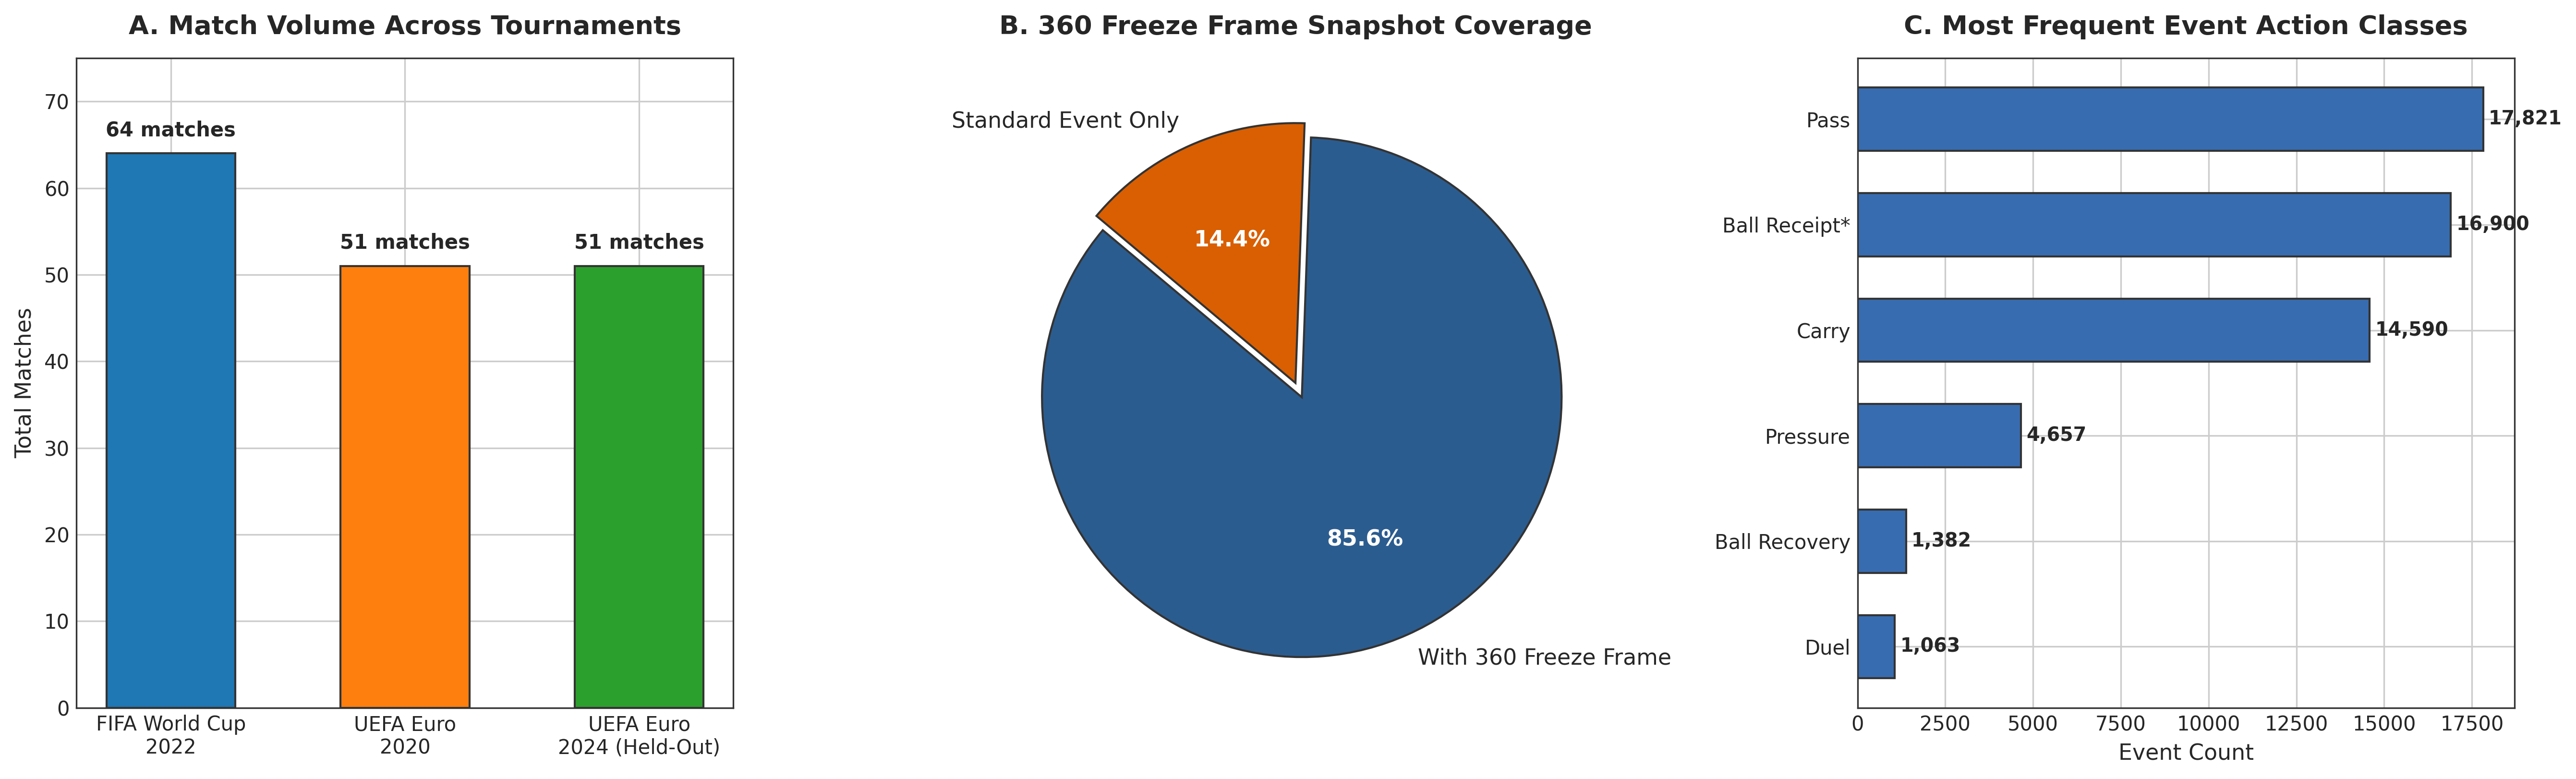


Figure 2: Pitch Spatial Event Density & Tactical Zones


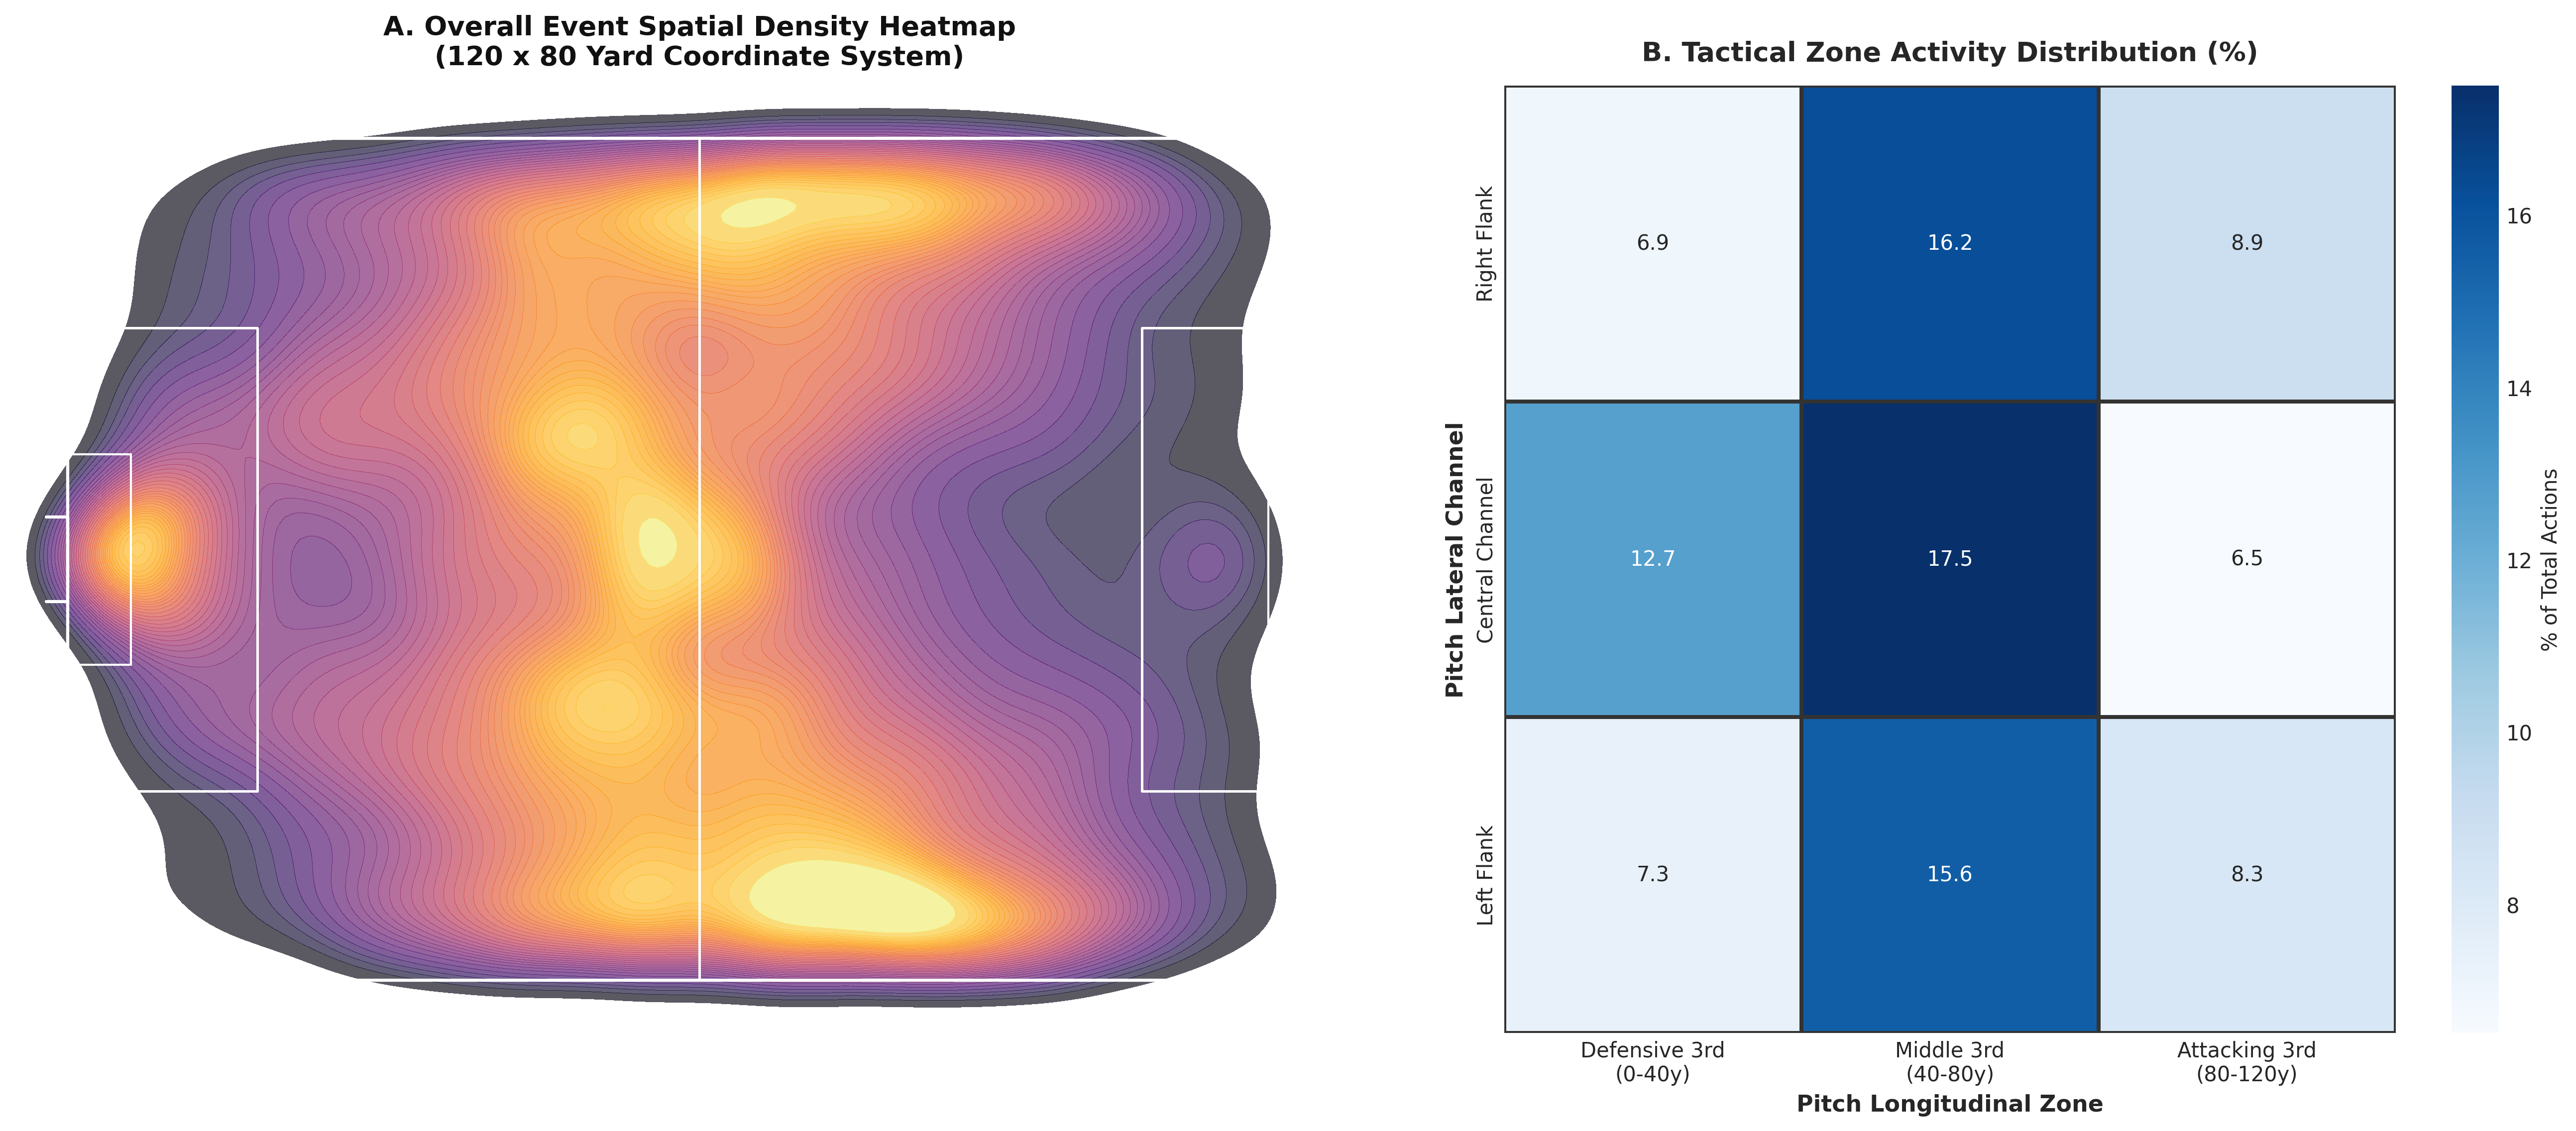


Figure 3: 360 Freeze Frame Density & Defensive Pressure


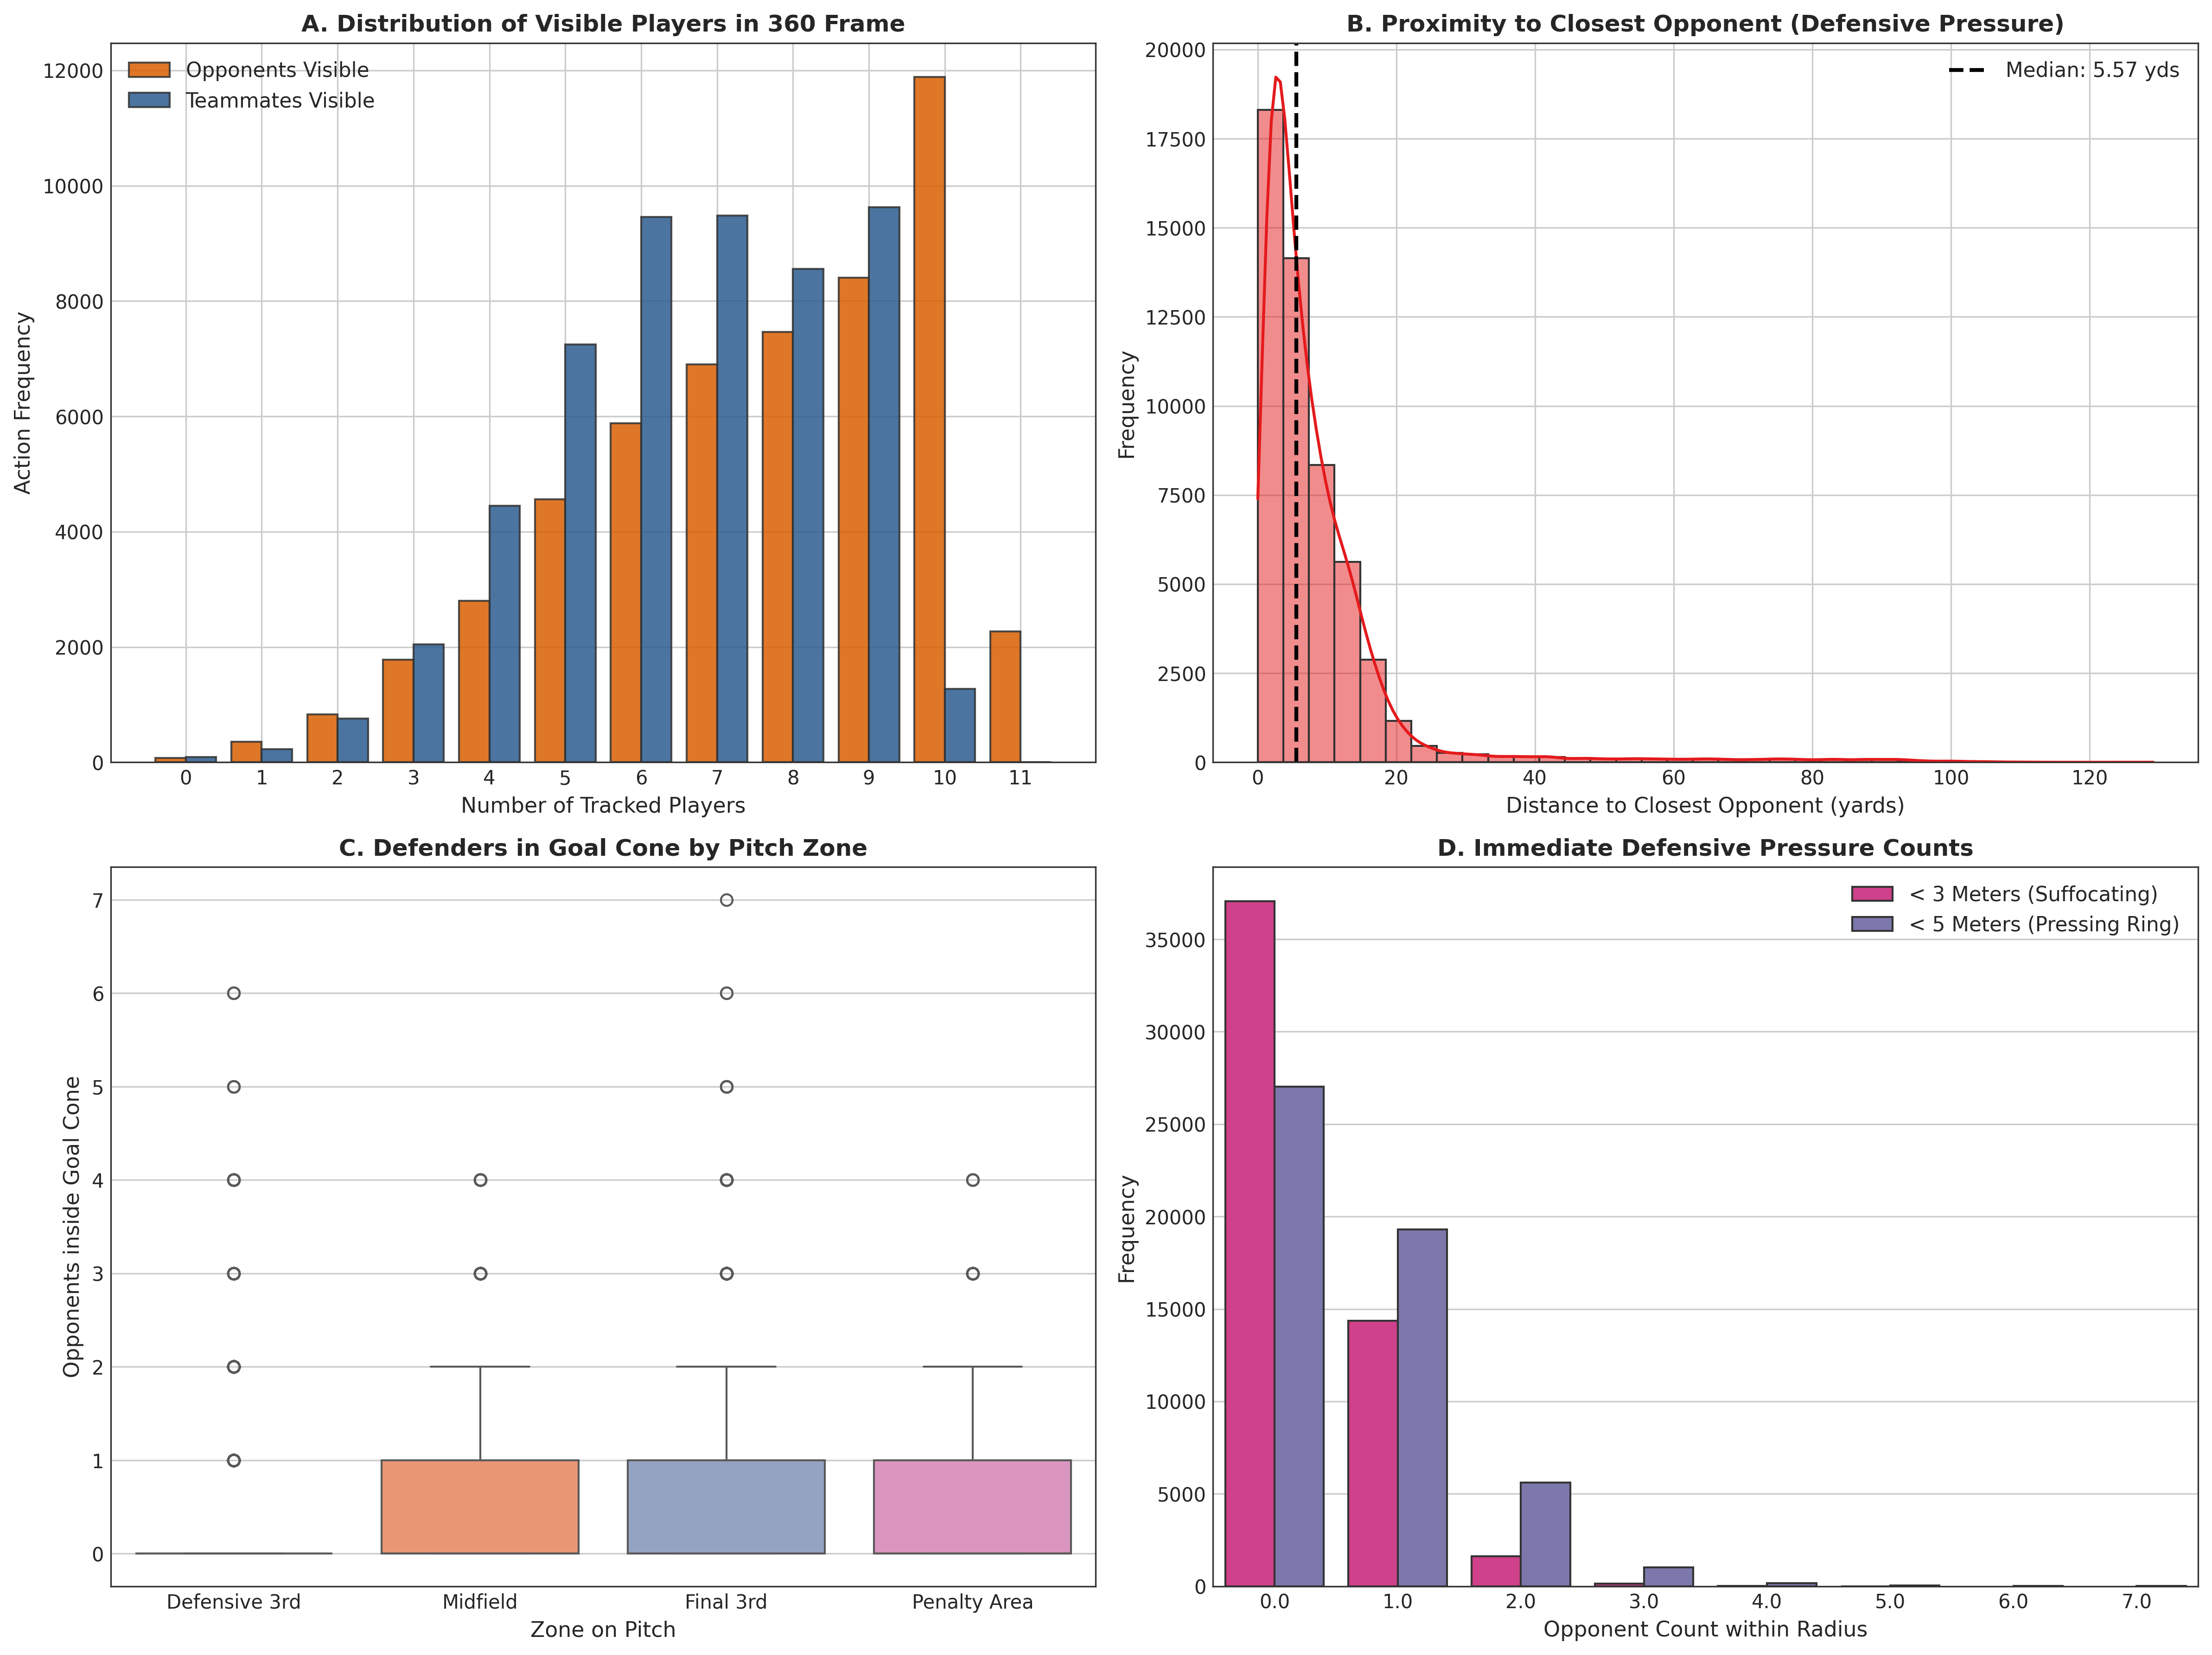


Figure 4: Action Types, Passing Angles & Possession Dynamics


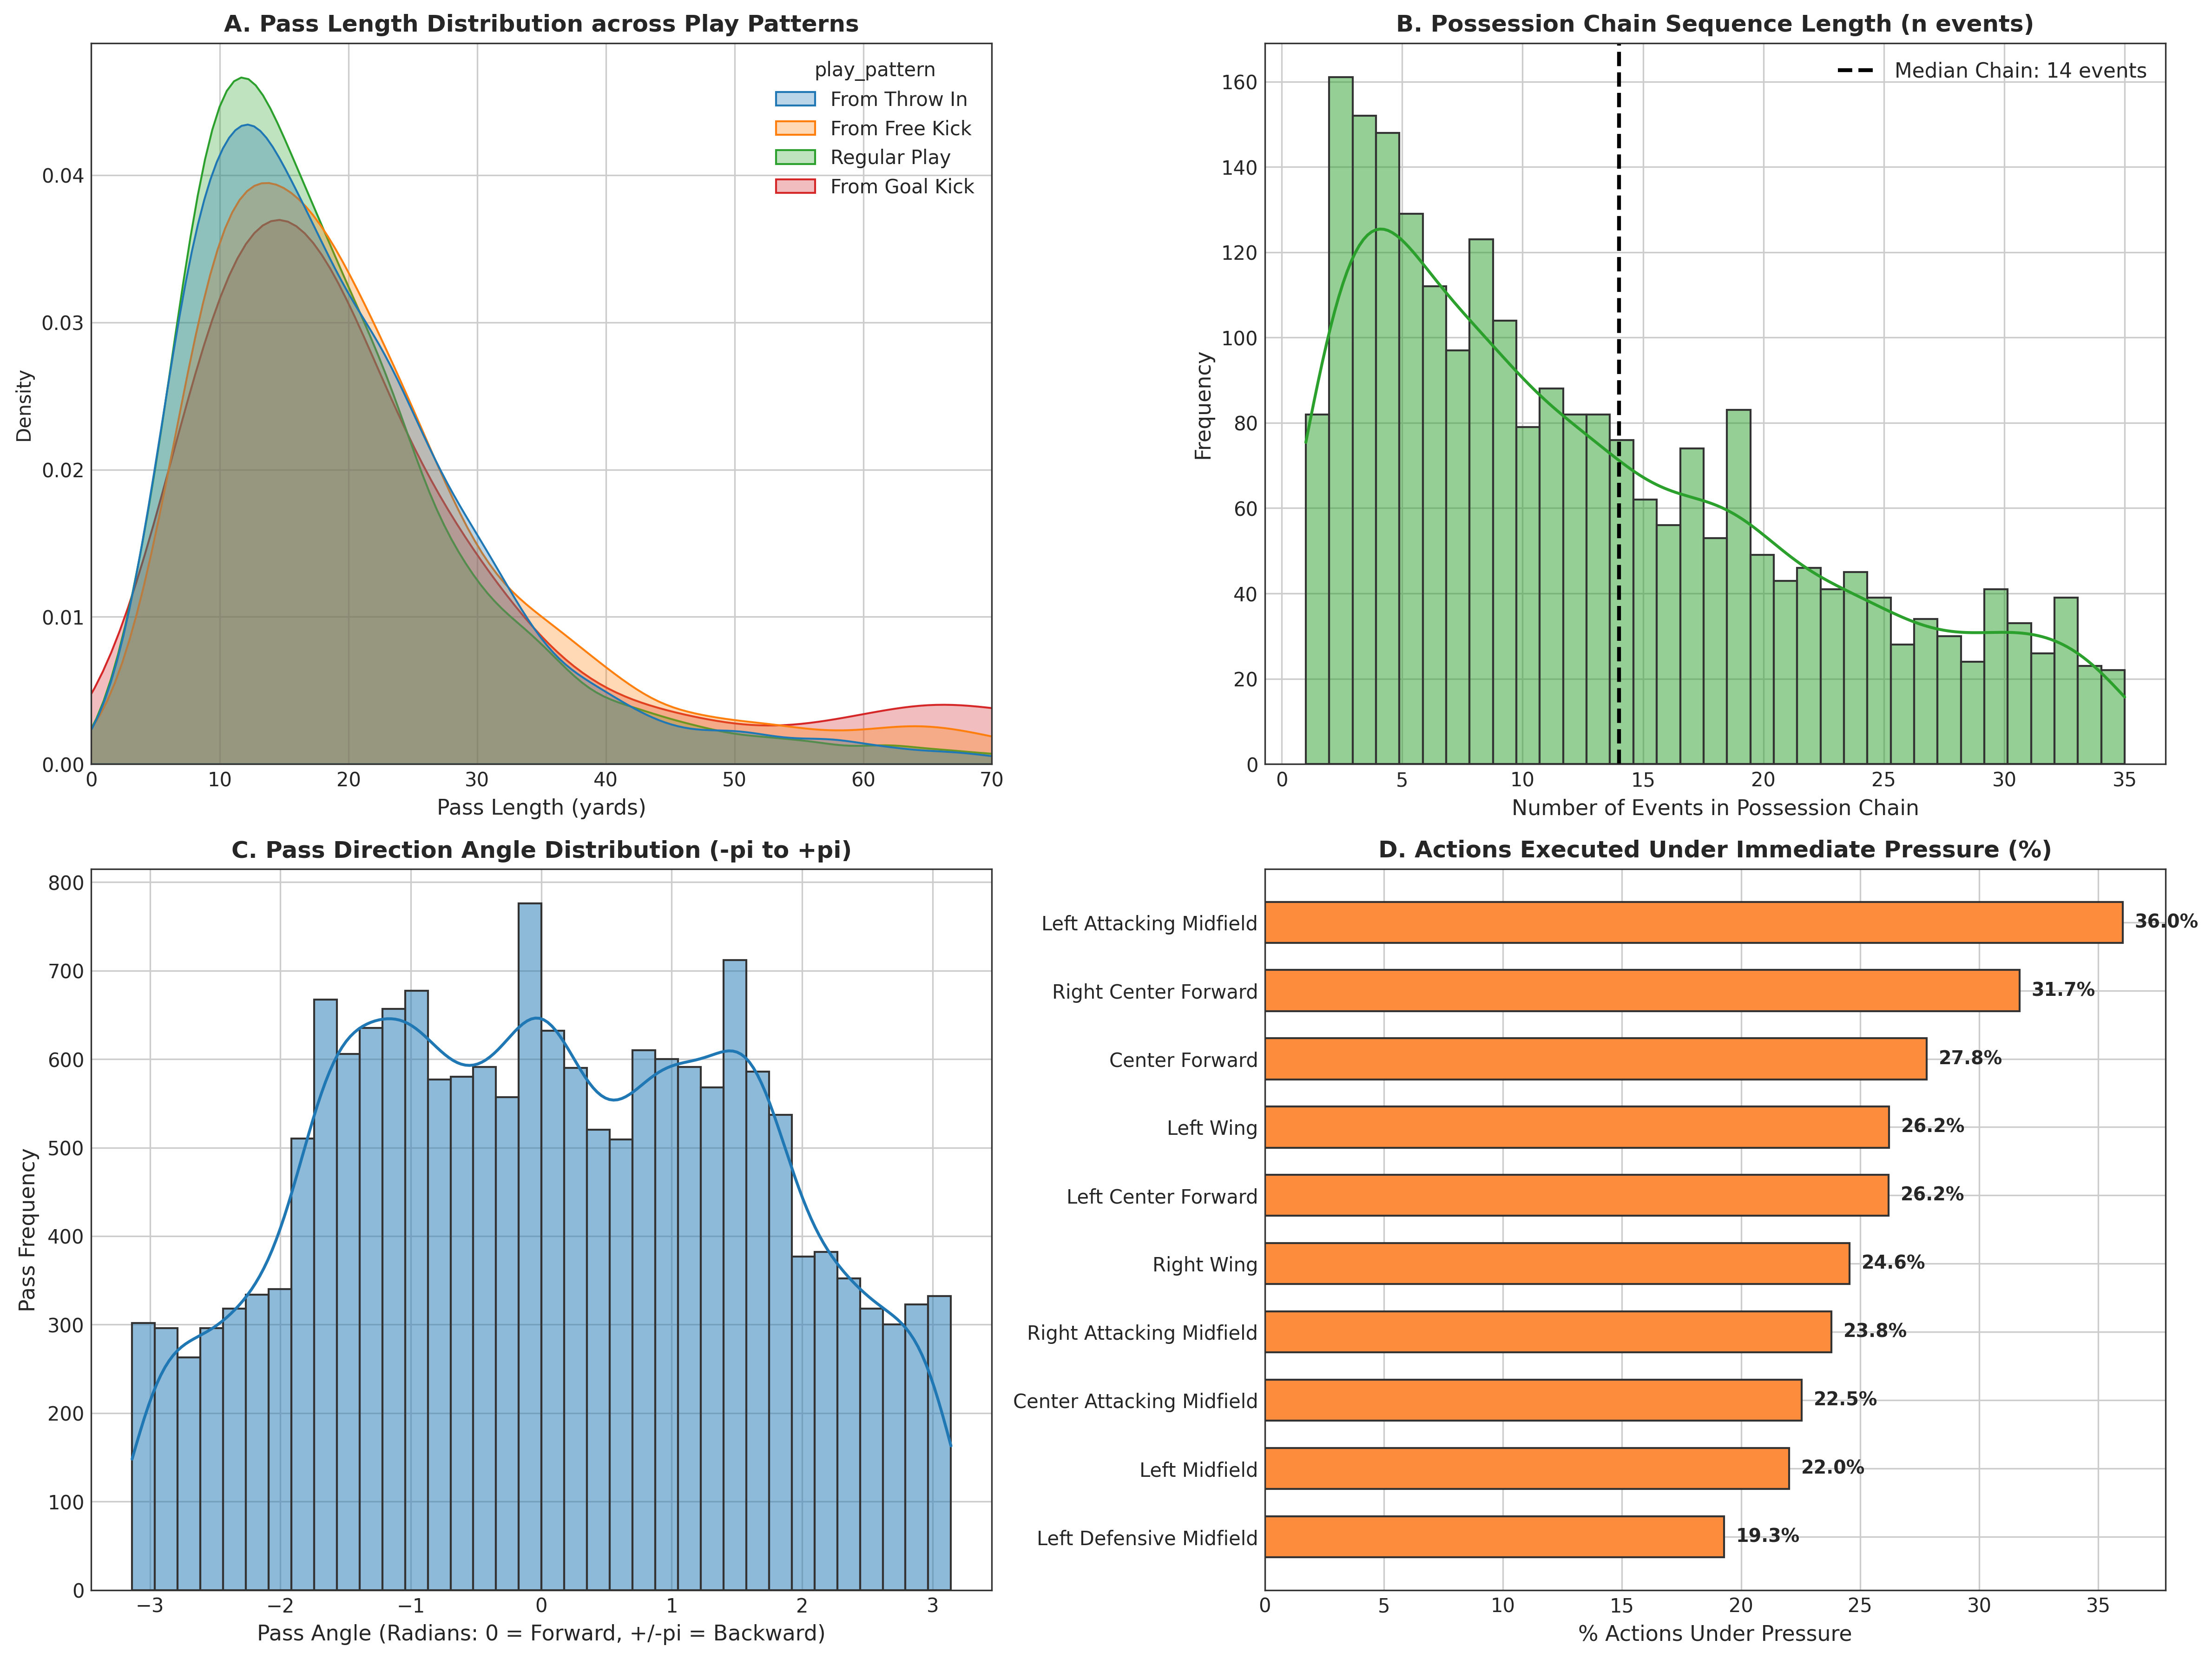


Figure 5: Feature Correlation Heatmap


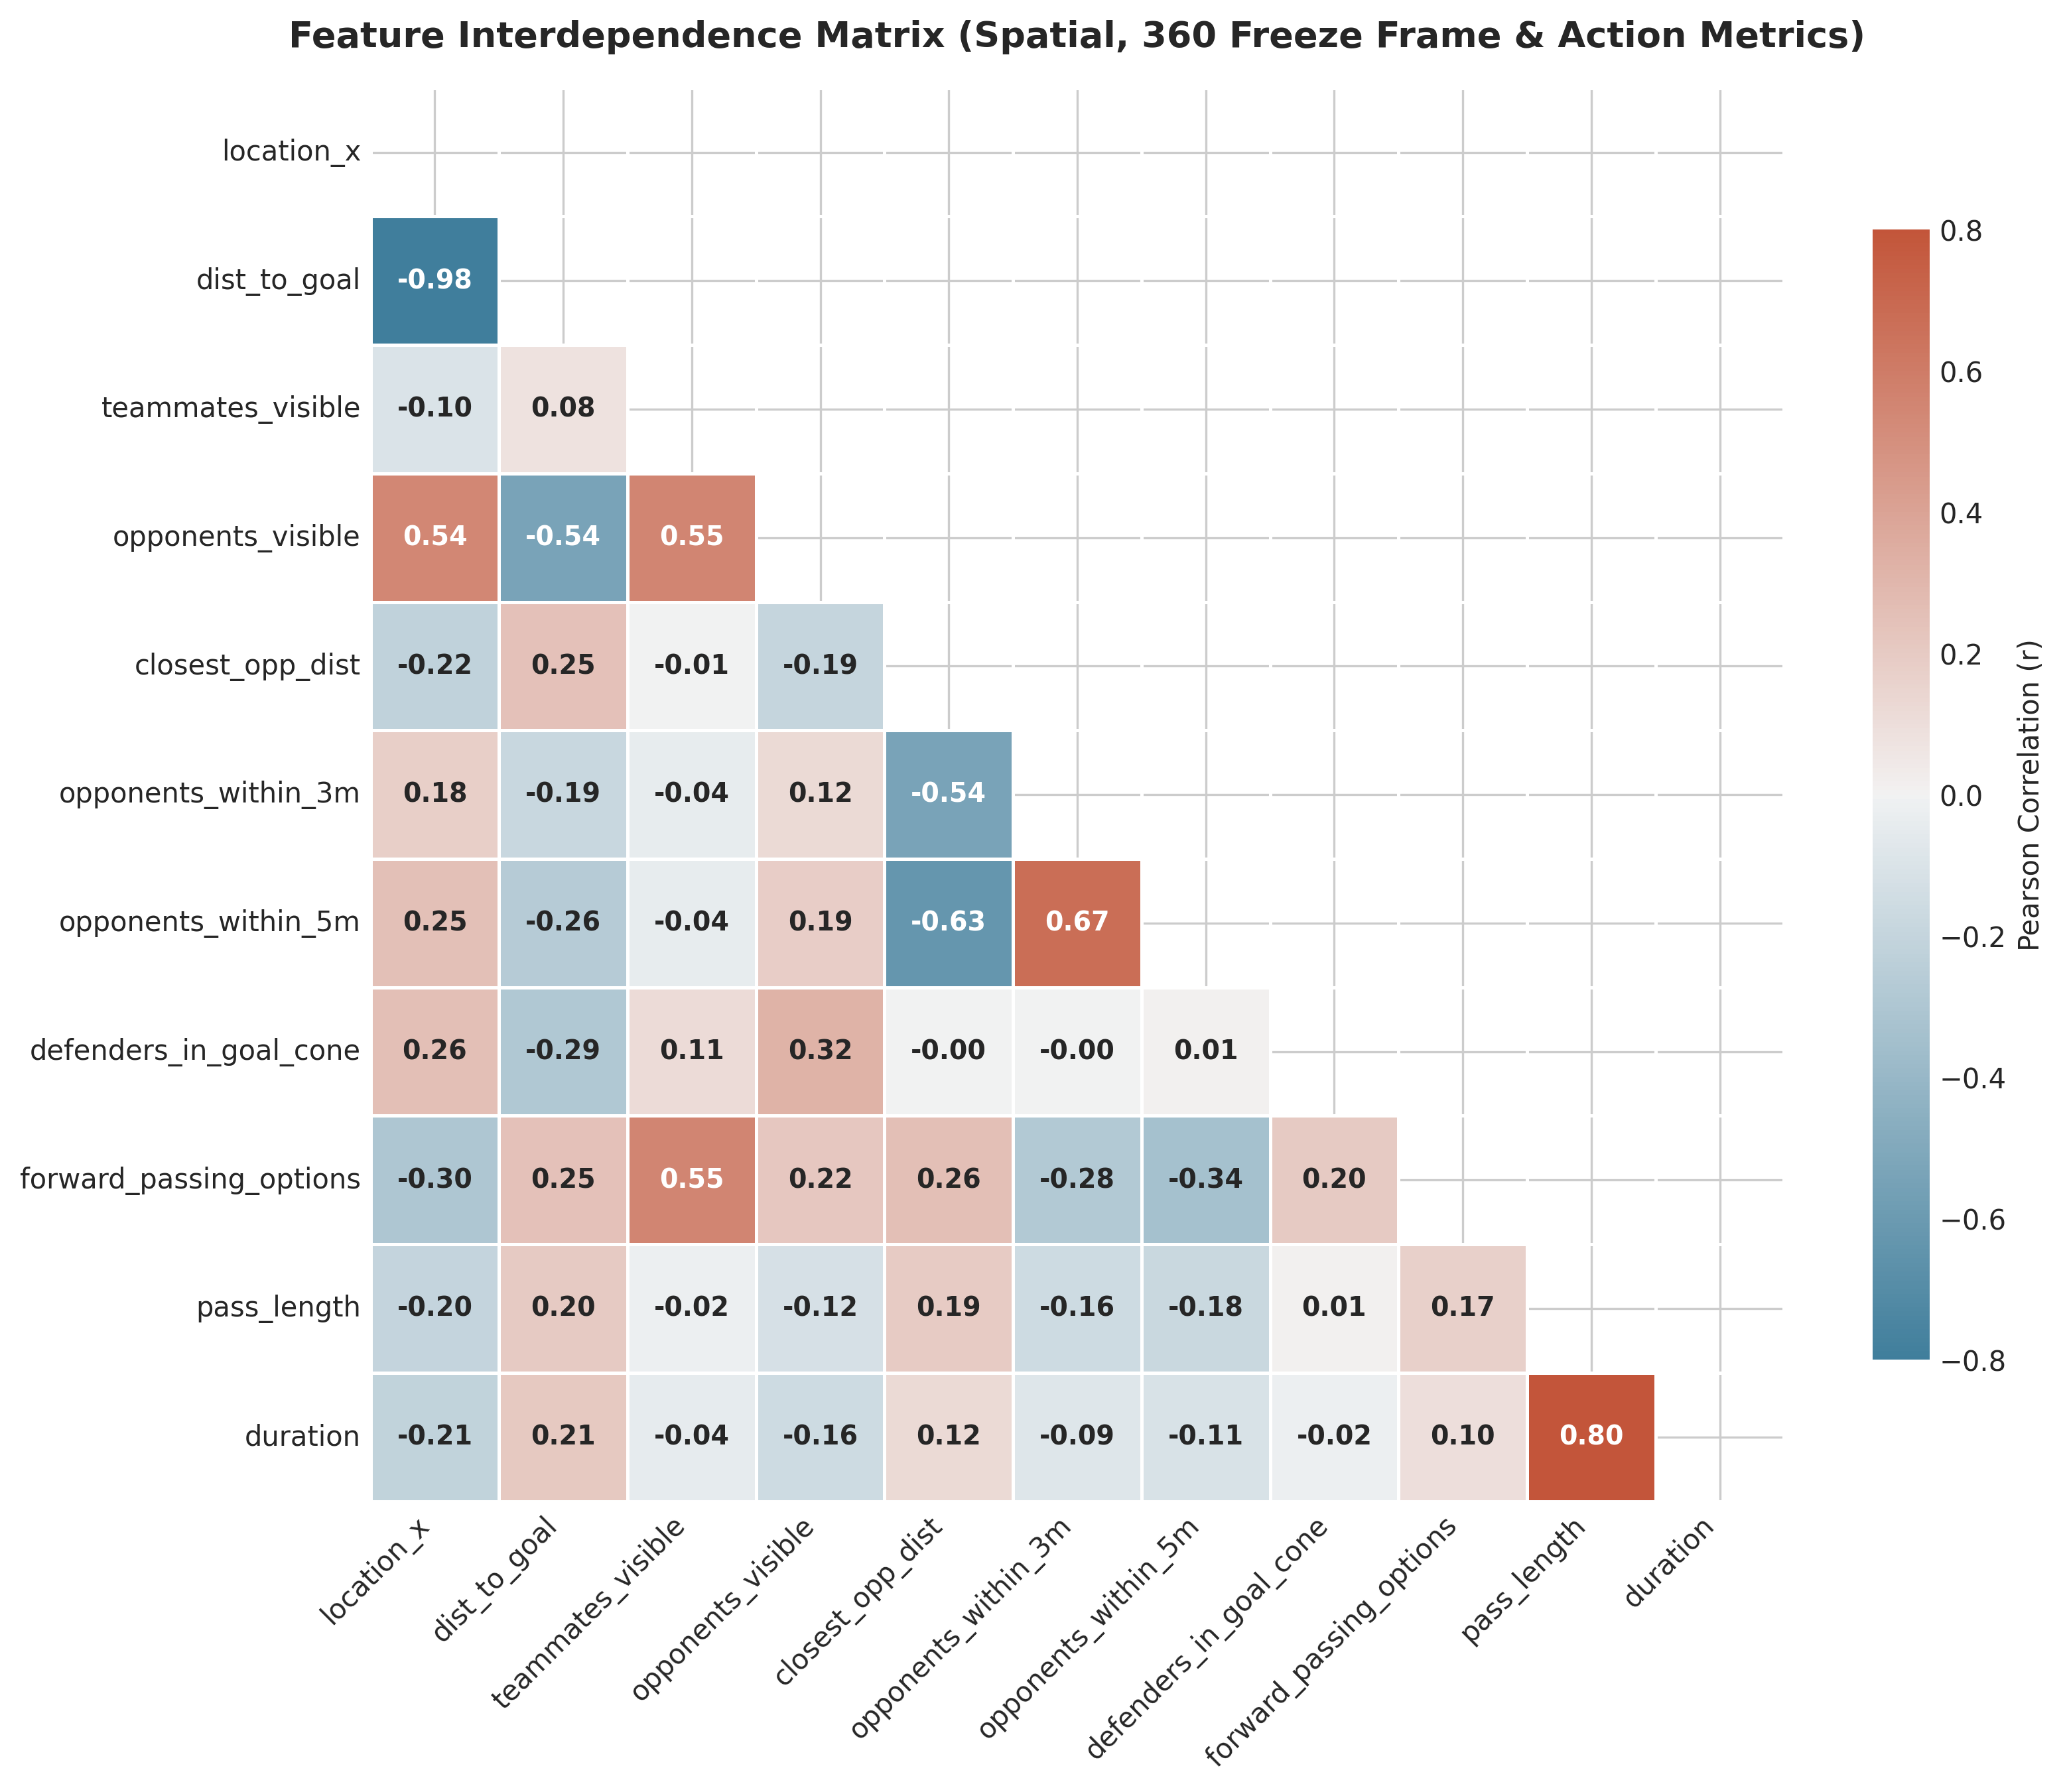


Figure 6: Player Spatial Profiles & Catalytic Indicators


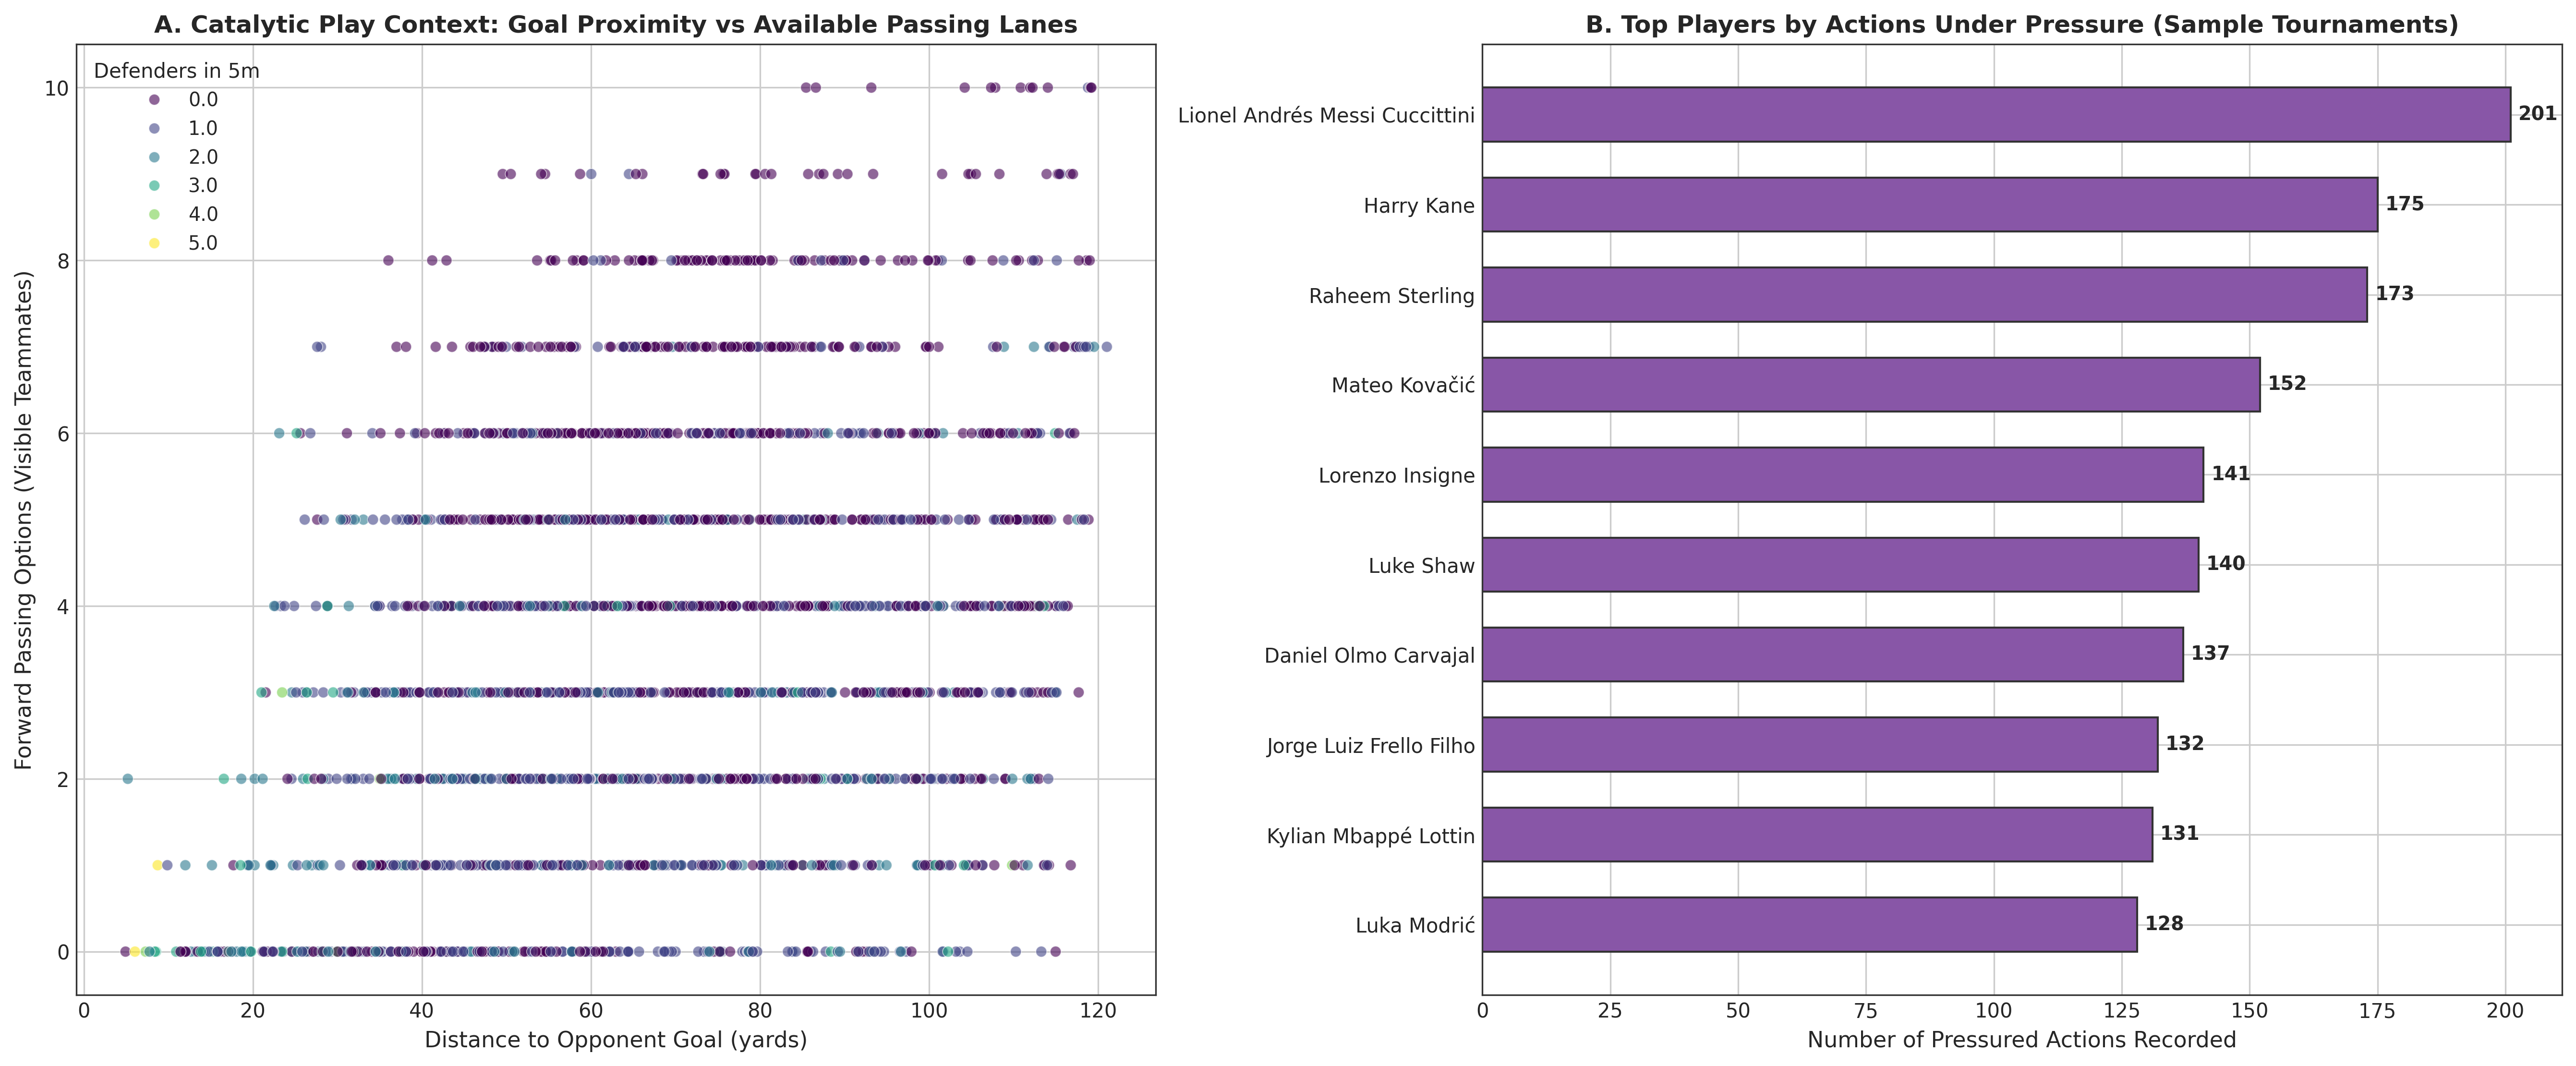

In [6]:
from IPython.display import Image, display

figure_files = [
    ('Figure 1: Dataset Architecture & Tournament Coverage', 'figures/fig1_dataset_architecture_and_coverage.png'),
    ('Figure 2: Pitch Spatial Event Density & Tactical Zones', 'figures/fig2_spatial_event_density_and_pitch_zones.png'),
    ('Figure 3: 360 Freeze Frame Density & Defensive Pressure', 'figures/fig3_statsbomb360_freeze_frame_pressure.png'),
    ('Figure 4: Action Types, Passing Angles & Possession Dynamics', 'figures/fig4_action_types_and_possession_chains.png'),
    ('Figure 5: Feature Correlation Heatmap', 'figures/fig5_feature_correlation_matrix.png'),
    ('Figure 6: Player Spatial Profiles & Catalytic Indicators', 'figures/fig6_player_spatial_profiles_and_vaep_indicators.png')
]

for title, path in figure_files:
    print(f"\n{'='*70}\n{title}\n{'='*70}")
    display(Image(filename=path))
